<a href="https://colab.research.google.com/github/TediBalint/AI-Jegyzetek/blob/master/Adaptive%20Learning%20Rates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Learning Rates

Ebben a notebookban az **adaptív tanulási ráták** módszereit vizsgáljuk.

## Tartalomjegyzék

1. Learning rate fontossága
2. Learning rate schedulerek
3. Warm-up stratégiák
4. Cyclical learning rates
5. Learning rate finder

## 1. Learning rate fontossága

### Túl nagy vs túl kicsi

| Learning rate | Probléma |
|---------------|----------|
| Túl nagy | Divergencia, oszcilláció |
| Túl kicsi | Lassú konvergencia, lokális min. |
| Optimális | Gyors és stabil konvergencia |

### Adaptív megközelítés

- Kezdetben nagy lépések (gyors tanulás)
- Később kisebb lépések (finom hangolás)

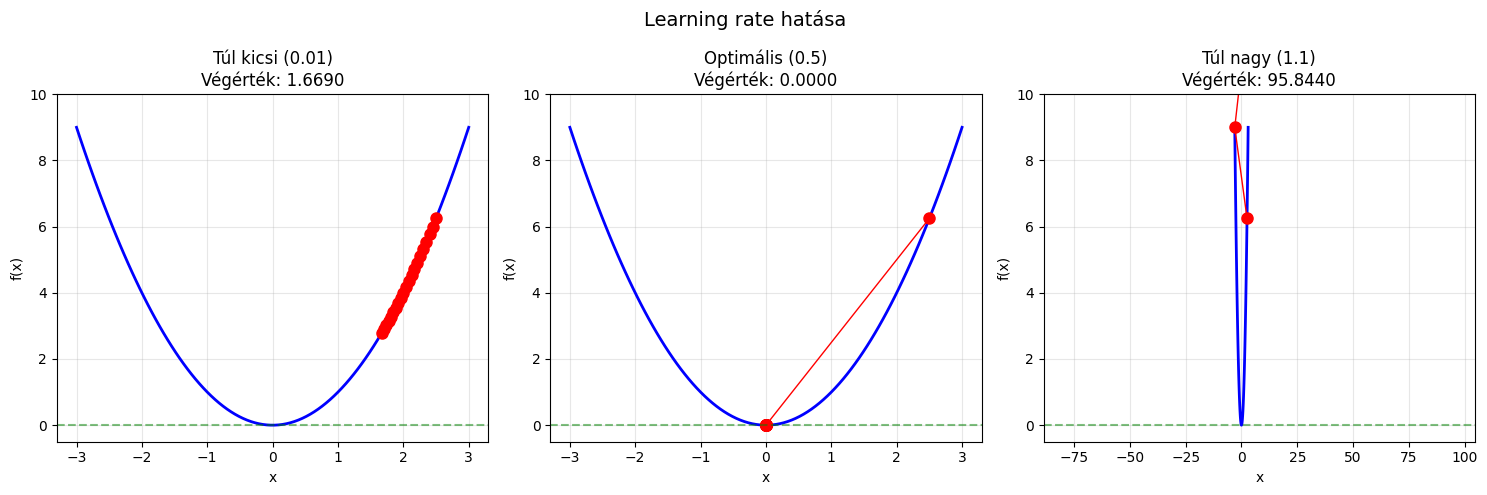

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR, OneCycleLR

np.random.seed(42)
torch.manual_seed(42)

# Learning rate hatása demonstráció
def quadratic(x):
    return x**2

def quadratic_grad(x):
    return 2 * x

def sgd_optimize(start, grad_fn, lr, steps):
    path = [start]
    x = start
    for _ in range(steps):
        x = x - lr * grad_fn(x)
        path.append(x)
    return np.array(path)

# Különböző learning rate-ek
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

x_range = np.linspace(-3, 3, 100)
lrs = [0.01, 0.5, 1.1]
titles = ['Túl kicsi (0.01)', 'Optimális (0.5)', 'Túl nagy (1.1)']

for ax, lr, title in zip(axes, lrs, titles):
    path = sgd_optimize(2.5, quadratic_grad, lr, 20)

    ax.plot(x_range, quadratic(x_range), 'b-', linewidth=2)
    ax.plot(path, quadratic(path), 'ro-', markersize=8, linewidth=1)
    ax.axhline(y=0, color='g', linestyle='--', alpha=0.5)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'{title}\nVégérték: {path[-1]:.4f}')
    ax.set_ylim(-0.5, 10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning rate hatása', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Learning rate schedulerek

### Főbb típusok

| Scheduler | Képlet | Jellemző |
|-----------|--------|----------|
| Step | $\eta_t = \eta_0 \gamma^{\lfloor t/s \rfloor}$ | Lépcsős csökkentés |
| Exponential | $\eta_t = \eta_0 \gamma^t$ | Folyamatos csökkenés |
| Cosine | $\eta_t = \frac{\eta_0}{2}(1 + \cos(\frac{\pi t}{T}))$ | Lágy csökkenés |

C:\Users\Balint\AppData\Local\Temp\ipykernel_8384\345982245.py:8: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


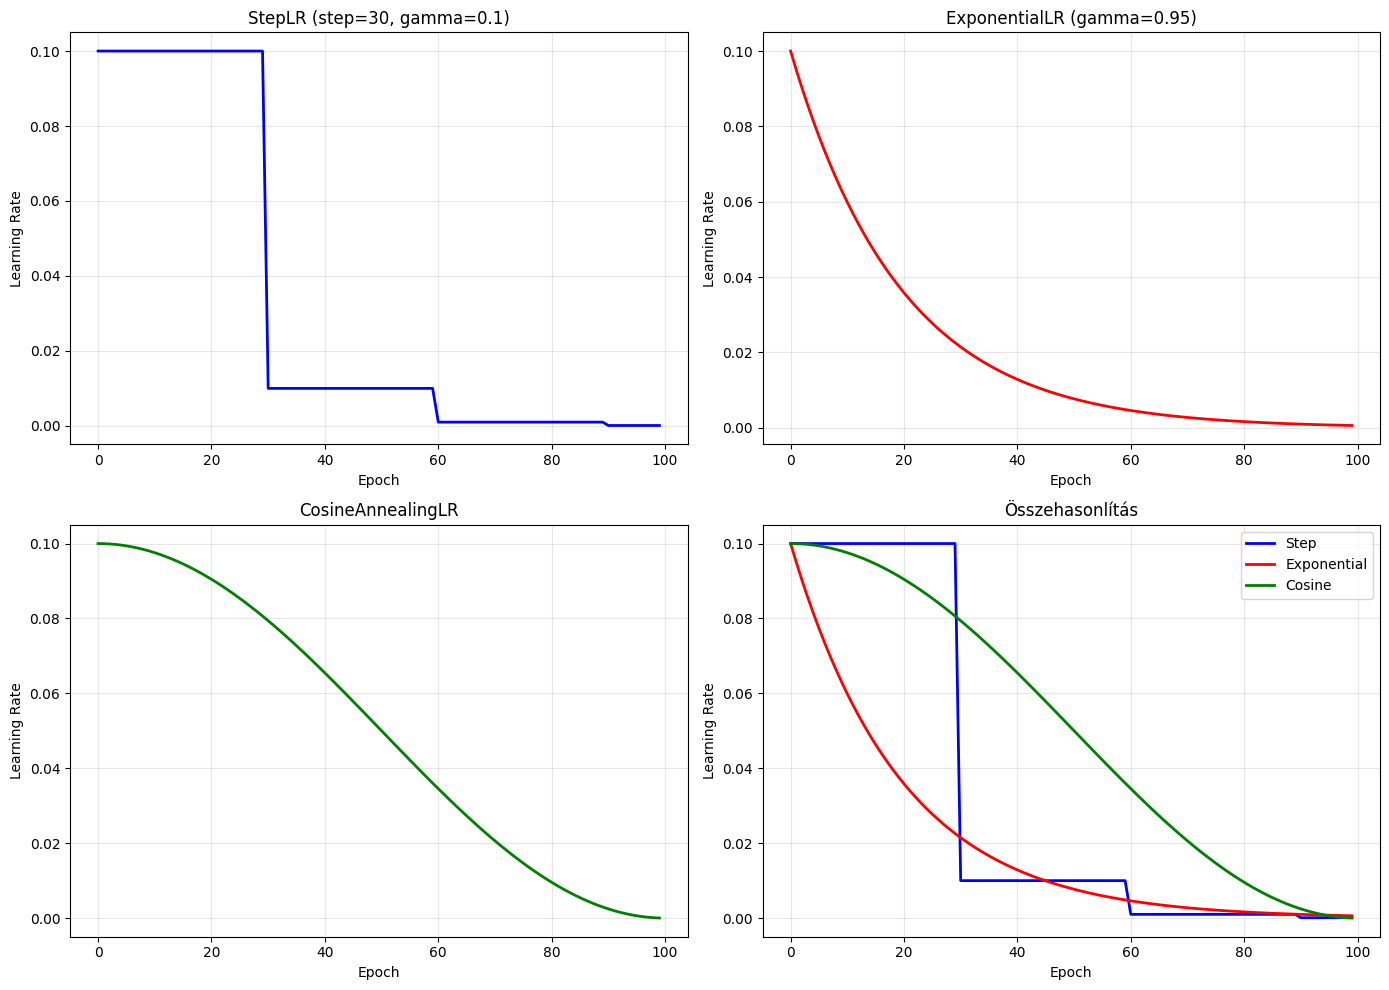

In [3]:
# Schedulerek összehasonlítása

def get_lr_schedule(scheduler_class, optimizer, epochs, **kwargs):
    scheduler = scheduler_class(optimizer, **kwargs)
    lrs = []
    for _ in range(epochs):
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    return lrs

epochs = 100
initial_lr = 0.1

# Dummy model és optimizer
model = nn.Linear(10, 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Step LR
optimizer = optim.SGD(model.parameters(), lr=initial_lr)
lrs_step = get_lr_schedule(StepLR, optimizer, epochs, step_size=30, gamma=0.1)
axes[0, 0].plot(lrs_step, 'b-', linewidth=2)
axes[0, 0].set_title('StepLR (step=30, gamma=0.1)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Learning Rate')
axes[0, 0].grid(True, alpha=0.3)

# Exponential LR
optimizer = optim.SGD(model.parameters(), lr=initial_lr)
lrs_exp = get_lr_schedule(ExponentialLR, optimizer, epochs, gamma=0.95)
axes[0, 1].plot(lrs_exp, 'r-', linewidth=2)
axes[0, 1].set_title('ExponentialLR (gamma=0.95)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Learning Rate')
axes[0, 1].grid(True, alpha=0.3)

# Cosine Annealing
optimizer = optim.SGD(model.parameters(), lr=initial_lr)
lrs_cos = get_lr_schedule(CosineAnnealingLR, optimizer, epochs, T_max=epochs)
axes[1, 0].plot(lrs_cos, 'g-', linewidth=2)
axes[1, 0].set_title('CosineAnnealingLR')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].grid(True, alpha=0.3)

# Összehasonlítás
axes[1, 1].plot(lrs_step, 'b-', linewidth=2, label='Step')
axes[1, 1].plot(lrs_exp, 'r-', linewidth=2, label='Exponential')
axes[1, 1].plot(lrs_cos, 'g-', linewidth=2, label='Cosine')
axes[1, 1].set_title('Összehasonlítás')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Warm-up stratégiák

### Miért kell warm-up?

| Probléma | Megoldás |
|----------|----------|
| Kezdeti instabilitás | Kis lr-ről indulás |
| Batch norm statisztikák | Fokozatos lr növelés |
| Transformer modellek | Linear warm-up |

### Warm-up típusok

1. **Linear warm-up**: $\eta_t = \eta_{max} \cdot \frac{t}{T_{warmup}}$
2. **Exponential warm-up**: $\eta_t = \eta_{max} \cdot (1 - e^{-t/\tau})$

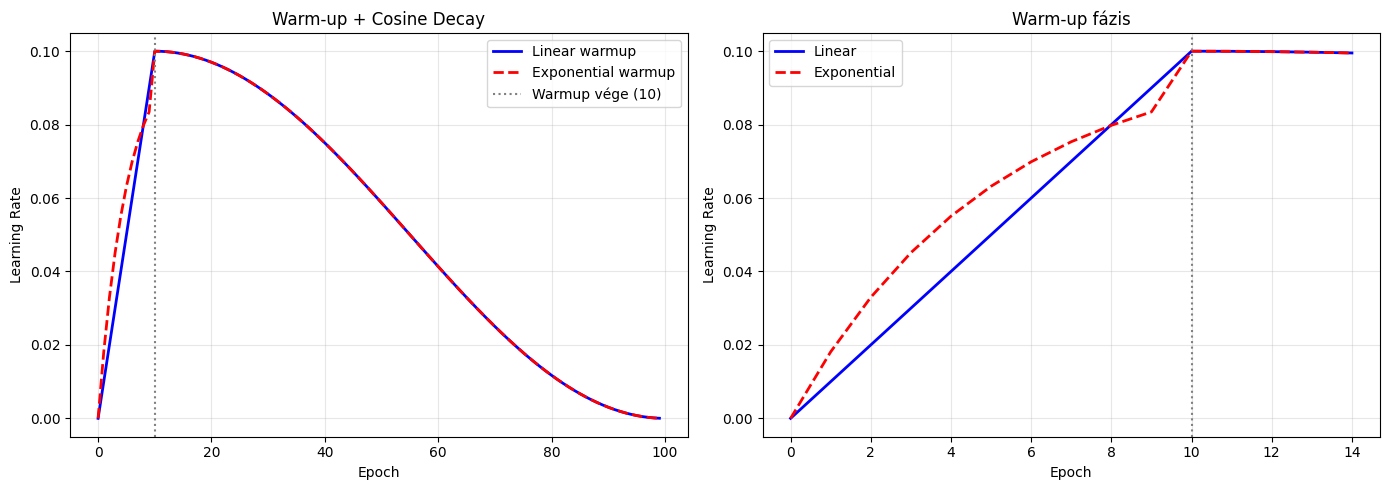

In [4]:
# Warm-up implementáció

def linear_warmup_schedule(epoch, warmup_epochs, max_lr, total_epochs):
    if epoch < warmup_epochs:
        return max_lr * epoch / warmup_epochs
    else:
        # Cosine decay after warmup
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return max_lr * 0.5 * (1 + np.cos(np.pi * progress))

def exponential_warmup_schedule(epoch, warmup_epochs, max_lr, total_epochs, tau=5):
    if epoch < warmup_epochs:
        return max_lr * (1 - np.exp(-epoch / tau))
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return max_lr * 0.5 * (1 + np.cos(np.pi * progress))

epochs = 100
warmup = 10
max_lr = 0.1

lrs_linear = [linear_warmup_schedule(e, warmup, max_lr, epochs) for e in range(epochs)]
lrs_exp = [exponential_warmup_schedule(e, warmup, max_lr, epochs) for e in range(epochs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Teljes schedule
axes[0].plot(lrs_linear, 'b-', linewidth=2, label='Linear warmup')
axes[0].plot(lrs_exp, 'r--', linewidth=2, label='Exponential warmup')
axes[0].axvline(x=warmup, color='gray', linestyle=':', label=f'Warmup vége ({warmup})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')
axes[0].set_title('Warm-up + Cosine Decay')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Warm-up fázis kinagyítva
axes[1].plot(range(warmup+5), lrs_linear[:warmup+5], 'b-', linewidth=2, label='Linear')
axes[1].plot(range(warmup+5), lrs_exp[:warmup+5], 'r--', linewidth=2, label='Exponential')
axes[1].axvline(x=warmup, color='gray', linestyle=':')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Warm-up fázis')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Cyclical learning rates

### CLR és OneCycleLR

| Módszer | Leírás |
|---------|--------|
| CLR | Ciklikus lr min és max között |
| OneCycleLR | Egy ciklus: warmup → max → decay |
| Super-convergence | Nagyon gyors tanulás |

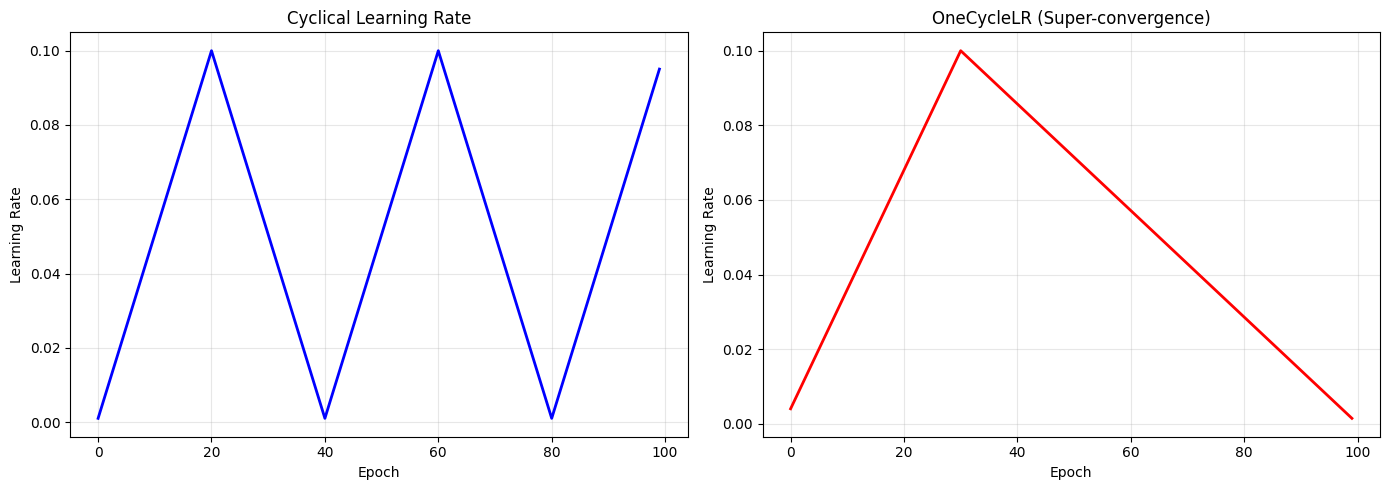

In [5]:
# Cyclical LR

def cyclical_lr(epoch, base_lr, max_lr, step_size):
    cycle = np.floor(1 + epoch / (2 * step_size))
    x = np.abs(epoch / step_size - 2 * cycle + 1)
    return base_lr + (max_lr - base_lr) * max(0, 1 - x)

# OneCycleLR szimulálás
def one_cycle_lr(epoch, total_epochs, max_lr, pct_start=0.3, div_factor=25, final_div=1e4):
    initial_lr = max_lr / div_factor
    min_lr = max_lr / final_div

    if epoch < total_epochs * pct_start:
        # Warm-up fázis
        progress = epoch / (total_epochs * pct_start)
        return initial_lr + (max_lr - initial_lr) * progress
    else:
        # Annealing fázis
        progress = (epoch - total_epochs * pct_start) / (total_epochs * (1 - pct_start))
        return max_lr - (max_lr - min_lr) * progress

epochs = 100

lrs_cyclic = [cyclical_lr(e, 0.001, 0.1, 20) for e in range(epochs)]
lrs_onecycle = [one_cycle_lr(e, epochs, 0.1) for e in range(epochs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lrs_cyclic, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')
axes[0].set_title('Cyclical Learning Rate')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lrs_onecycle, 'r-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('OneCycleLR (Super-convergence)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Learning rate finder

### Automatikus lr keresés

1. Exponenciálisan növekvő lr
2. Loss monitorozása
3. Optimális lr: meredek csökkenés előtt

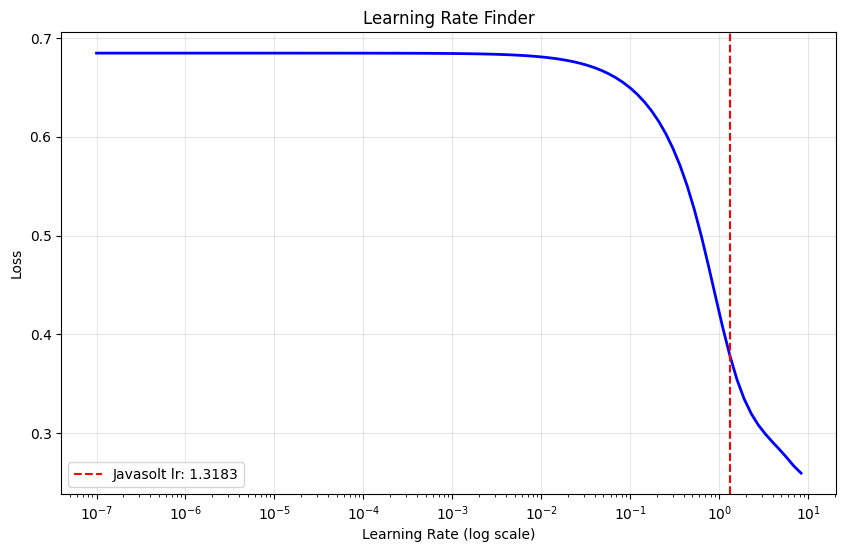

Javasolt learning rate: 1.318257


In [6]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Adat
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)

def lr_finder(model, X, y, start_lr=1e-7, end_lr=10, num_iter=100):
    """
    Learning rate finder implementáció.
    """
    model_copy = type(model)()  # Új példány
    model_copy.load_state_dict(model.state_dict())

    optimizer = optim.SGD(model_copy.parameters(), lr=start_lr)
    criterion = nn.BCELoss()

    # Exponenciális lr növelés
    lr_mult = (end_lr / start_lr) ** (1 / num_iter)

    lrs = []
    losses = []
    best_loss = float('inf')

    for i in range(num_iter):
        # Forward
        outputs = model_copy(X).squeeze()
        loss = criterion(outputs, y)

        # Ha a loss explodál, megállunk
        if loss.item() > 4 * best_loss or torch.isnan(loss):
            break

        if loss.item() < best_loss:
            best_loss = loss.item()

        lrs.append(optimizer.param_groups[0]['lr'])
        losses.append(loss.item())

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # LR növelés
        for param_group in optimizer.param_groups:
            param_group['lr'] *= lr_mult

    return lrs, losses

# Model
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model = SimpleNet()
lrs, losses = lr_finder(model, X_train_t, y_train_t)

# Vizualizáció
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(lrs, losses, 'b-', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)')
ax.set_ylabel('Loss')
ax.set_title('Learning Rate Finder')
ax.grid(True, alpha=0.3)

# Ajánlott lr jelölése (loss minimuma előtti régió)
min_loss_idx = np.argmin(losses)
suggested_lr = lrs[max(0, min_loss_idx - 10)]  # Kicsit a minimum előtt
ax.axvline(x=suggested_lr, color='r', linestyle='--', label=f'Javasolt lr: {suggested_lr:.4f}')
ax.legend()

plt.show()

print(f"Javasolt learning rate: {suggested_lr:.6f}")

## Összefoglalás

### Learning rate schedulerek:

| Scheduler | Mikor használd |
|-----------|---------------|
| StepLR | Egyszerű, kiszámítható |
| ExponentialLR | Folyamatos csökkenés |
| CosineAnnealingLR | SOTA eredmények |
| OneCycleLR | Super-convergence |

### Warm-up:

| Típus | Használat |
|-------|----------|
| Linear | Transformer modellek |
| Exponential | Batch norm esetén |

### Learning rate finder:

- Automatikus lr keresés
- Loss görbe elemzése
- Meredek csökkenés előtti érték